
# Noise Hand Calculations: LTspice vs ngspice

Este notebook calcula a mano el ruido de un NMOS con el modelo de primer orden (Level 1) de `razavi_cmos.lib` y lo compara contra las simulaciones `.noise` de **LTspice** (`Noise_A`, `Noise_B` y `Noise_C`) y contra las de ngspice (`ngspice/Razavi/Noise_Razavi.cir`). Las unidades son SI: metros, volts, amperes, hertz; las densidades espectrales están en V$^2$/Hz o A$^2$/Hz.

Los tres circuitos de fuente común comparten el transistor ($V_{GS}=0.9$ V, $W=1\,\mu$m, $L=0.18\,\mu$m):

| Circuito | Netlist LTspice | Carga | Qué aísla |
|---|---|---|---|
| **A** | `Noise_A.net` | Inductor de 1 GH (corto en DC, abierto en AC) desde 0.9 V | El ruido del transistor solo ($V_{DS}=0.9$ V) |
| **B** | `Noise_B.net` | $R_D=10\,\text{k}\Omega$ desde $V_{DD}=1.8$ V | El ruido del transistor más el de la resistencia de carga |
| **C** | `Noise_C.net` | Igual que A, con `xnchr` ($r_d=r_s=200\,\Omega$) | El ruido de las resistencias parásitas |

**La diferencia clave entre simuladores es el ruido flicker.** El ruido térmico del canal, el de $R_D$ y el de $r_d$, $r_s$ se calculan igual en LTspice y en ngspice. En cambio, el flicker del Level 1 usa **fórmulas distintas** (sección *Ruido flicker*), por lo que el parámetro `kf` de `razavi_cmos.lib` es distinto en `LTspice/Razavi` y en `ngspice/Razavi`.

**Convención del código.** Igual que en `ngspice/Razavi/Noise_Hand_Calculations.ipynb`, no se definen funciones propias: cada ecuación se escribe completa, una vez por circuito, con el sufijo del circuito (`_A`, `_B`, `_C`).

Este notebook se ejecuta desde `LTspice/Razavi`; los resultados de ngspice se leen de `../../ngspice/Razavi`.


## Imports

Se cargan NumPy y Matplotlib para los cálculos y las gráficas, `spicelib` para leer los archivos `.raw` de ngspice, y `prettytable` y `si_prefix` para mostrar los resultados en notación de ingeniería. Si la fuente Arial no está instalada, Matplotlib usa otra de la lista sin mostrar advertencias.

In [1]:
# Paso 1: importar las librerias
import logging
import re

import numpy as np                  # calculos numericos
import matplotlib.pyplot as plt     # graficas

from spicelib import RawRead        # lee los archivos .raw de ngspice

from si_prefix import si_format as num2eng   # imprime con prefijos de ingenieria (n, u, m, k...)
from prettytable import PrettyTable          # tablas de resultados

# Paso 2: configurar el estilo de las graficas
# Se usa Arial si esta instalada; si no, matplotlib toma la siguiente fuente de la lista.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)   # oculta avisos de fuente faltante
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

C_HAND = "#2a78d6"     # calculo a mano
C_SIM = "#eb6834"      # ngspice
C_AUX = "#52514e"      # lineas auxiliares

# Paso 3: regla del trapecio (se llama trapezoid en versiones recientes de numpy)
trapz = getattr(np, "trapezoid", None) or np.trapz

## Constantes y parámetros del modelo

La densidad espectral del ruido térmico depende de la temperatura de la simulación. ngspice usa `temp=27` °C, es decir $T=300.15$ K. La capacitancia de óxido por unidad de área es

$$C_{ox}=\frac{\epsilon_{ox}}{t_{ox}}, \qquad \epsilon_{ox}=3.9\,\epsilon_0,$$

con $\epsilon_0=8.854214871\times10^{-12}$ F/m, el valor que usa ngspice.

Además de los parámetros de `Hand_Calculations.ipynb`, el ruido necesita:

- $K_F$ y $A_F$: coeficiente y exponente del ruido flicker.
- $r_d$ y $r_s$: resistencias serie de drenador y fuente, que aportan su propio ruido térmico $4kT/R$.

Los valores de $K_F$ y $A_F$ de `razavi_cmos.lib` son didácticos y **dependen del simulador** (ver la sección de ruido flicker): en `LTspice/Razavi` $K_F=2.87\times10^{-24}$ (NMOS) y $6.7\times10^{-25}$ (PMOS); en `ngspice/Razavi` $K_F=3\times10^{-29}$ y $3.5\times10^{-30}$. Con $W=1\,\mu$m y $L=0.18\,\mu$m ambos dan el mismo flicker: 43 µV/$\sqrt{\text{Hz}}$ a 1 Hz en el NMOS.

In [2]:
# Paso 1: constantes fisicas y temperatura (ngspice usa temp = 27 C)
k = 1.380649e-23        # Constante de Boltzmann (J/K)
TEMP = 27.0             # Temperatura (C)
T = TEMP + 273.15       # Temperatura (K)
eps0 = 8.854214871e-12  # Permitividad del vacio (F/m)

# Paso 2: geometria del transistor y polarizacion (los tres circuitos comparten transistor)
W = 1e-6                # Ancho del canal (m)
L = 0.18e-6             # Largo del canal (m)
VGS = 0.9               # Voltaje compuerta-fuente (V)
VDD = 1.8               # Alimentacion del circuito B (V)
RD = 10e3               # Circuito B: resistencia de carga (ohm)

# Paso 3: parametros Level 1 (los mismos que en Hand_Calculations.ipynb)
kp = 100e-6             # Parametro de transconductancia de proceso (A/V**2)
VTH0 = 0.4              # Voltaje de umbral con VSB = 0 (V)
gamma = 0.4             # Coeficiente de efecto de cuerpo (V**0.5)
phi = 0.3               # Potencial de superficie (V)
lmbda = 0.1             # Modulacion de longitud de canal (1/V)
tox = 40e-10            # Espesor de oxido (m)

# Paso 4: parametros de ruido (los de LTspice/Razavi/razavi_cmos.lib, modelo nch)
kf = 2.87e-24           # Coeficiente flicker de LTspice (NMOS)
kf_ng = 3e-29           # Coeficiente flicker de ngspice (NMOS), solo para comparar
af = 1.0                # Exponente flicker (con af = 1 no interviene en la expresion de LTspice)
rd = 200.0              # Circuito C: resistencia serie de drenador (ohm)
rs = 200.0              # Circuito C: resistencia serie de fuente (ohm)

# Paso 5: capacitancias que cargan el nodo de salida (solo afectan el ruido de salida a alta frecuencia)
CGDO = 9.548e-10        # Traslape compuerta-drenador por unidad de ancho (F/m)
Cj = 9.81e-4            # Capacitancia de union de fondo (F/m**2)
Cjsw = 1.19e-10         # Capacitancia de union de pared lateral (F/m)
LD = 0.48e-6            # Longitud de difusion (m)

# Paso 6: cantidades derivadas
Cox = 3.9 * eps0 / tox          # Capacitancia de oxido por unidad de area (F/m**2)
beta = kp * W / L               # kp * W / L (A/V**2)
AS = W * LD                     # Area de la difusion de drenador (m**2)
PS = 2 * W + 2 * LD             # Perimetro de la difusion de drenador (m)
Cdb = Cj * AS + Cjsw * PS       # Capacitancia de union drenador-cuerpo (F)
Cgd = CGDO * W                  # En saturacion solo queda el traslape compuerta-drenador (F)
Cout = Cdb + Cgd                # La compuerta es tierra de AC: Cdb y Cgd ven el nodo de salida (F)

print(f"T = {T:.2f} K, 4kT = {4*k*T:.4e} J, Cox = {num2eng(Cox)}F/m^2, beta = {num2eng(beta)}A/V^2, Cout = {num2eng(Cout)}F")

T = 300.15 K, 4kT = 1.6576e-20 J, Cox = 8.6 mF/m^2, beta = 555.6 µA/V^2, Cout = 1.8 fF


## Punto de operación

El ruido del canal depende de $g_m$ y de $I_D$, así que primero se calcula el punto de operación con las mismas ecuaciones de `Hand_Calculations.ipynb`:

$$V_{TH}=V_{TH0}+\gamma\left(\sqrt{\phi+V_{SB}}-\sqrt{\phi}\right), \qquad V_{ov}=V_{GS}-V_{TH},$$
$$I_D=\frac{1}{2}k_p\frac{W}{L}V_{ov}^2(1+\lambda V_{DS}), \qquad g_m=k_p\frac{W}{L}V_{ov}(1+\lambda V_{DS}),$$
$$g_{mb}=g_m\frac{\gamma}{2\sqrt{\phi+V_{SB}}}, \qquad g_{ds}=\frac{\lambda I_D}{1+\lambda V_{DS}}.$$

### Circuito A

Con la carga ideal, $V_{DS}=0.9$ V y $V_{SB}=0$.

### Circuito B

El drenador está conectado a $V_{DD}$ por $R_D$, así que $V_{DS}=V_{DD}-R_DI_D$ y $I_D$ depende de $V_{DS}$ por la modulación de canal. Con $I_0=\frac{1}{2}k_p\frac{W}{L}V_{ov}^2$ y $I_D=I_0(1+\lambda V_{DS})$ se despeja

$$V_{DS}=\frac{V_{DD}-R_DI_0}{1+\lambda R_DI_0}.$$

### Circuito C

Con $r_s$ y $r_d$ en serie, el transistor intrínseco ve voltajes distintos a los externos:

$$V_{GS}'=V_{G}-I_Dr_s, \qquad V_{SB}'=I_Dr_s, \qquad V_{DS}'=V_{D}-I_D(r_d+r_s).$$

Como $V_{GS}'$, $V_{SB}'$ y $V_{DS}'$ dependen de $I_D$, y $I_D$ depende de ellos, el punto de operación se resuelve numéricamente con bisección sobre $I_D$.

In [3]:
# ===================== Circuito A: carga ideal =====================
# Paso 1: voltajes del circuito. El drenador esta fijo a 0.9 V y la fuente a tierra.
VDS_A = 0.9
VSB_A = 0.0

# Paso 2: voltaje de umbral con efecto de cuerpo y voltaje de sobreexcitacion
VTH_A = VTH0 + gamma * (np.sqrt(phi + VSB_A) - np.sqrt(phi))
Vov_A = VGS - VTH_A
VDSat_A = Vov_A                 # En saturacion se necesita VDS >= VDSat = VGS - VTH

# Paso 3: corriente de drenador y parametros de pequena senal
ID_A = 0.5 * beta * Vov_A**2 * (1 + lmbda * VDS_A)
gm_A = beta * Vov_A * (1 + lmbda * VDS_A)
gmb_A = gm_A * gamma / (2 * np.sqrt(phi + VSB_A))
gds_A = lmbda * ID_A / (1 + lmbda * VDS_A)


# ===================== Circuito B: carga resistiva RD =====================
# Paso 1: la fuente esta a tierra, asi que VSB = 0 y VTH no cambia
VSB_B = 0.0
VTH_B = VTH0 + gamma * (np.sqrt(phi + VSB_B) - np.sqrt(phi))
Vov_B = VGS - VTH_B
VDSat_B = Vov_B

# Paso 2: VDS = VDD - RD*ID, e ID depende de VDS. Con I0 = 0.5*beta*Vov^2 (ID sin modulacion de canal)
# se tiene ID = I0*(1 + lmbda*VDS), y al despejar VDS queda una expresion cerrada.
I0_B = 0.5 * beta * Vov_B**2
VDS_B = (VDD - RD * I0_B) / (1 + lmbda * RD * I0_B)

# Paso 3: corriente de drenador y parametros de pequena senal con el VDS ya calculado
ID_B = 0.5 * beta * Vov_B**2 * (1 + lmbda * VDS_B)
gm_B = beta * Vov_B * (1 + lmbda * VDS_B)
gmb_B = gm_B * gamma / (2 * np.sqrt(phi + VSB_B))
gds_B = lmbda * ID_B / (1 + lmbda * VDS_B)


# ===================== Circuito C: resistencias serie rd y rs =====================
# Paso 1: con rs y rd en serie, el transistor intrinseco ve voltajes distintos a los externos:
#   VGS' = VGS - ID*rs,  VSB' = ID*rs,  VDS' = VD - ID*(rd + rs)
# ID depende de esos voltajes, asi que se busca por biseccion el ID que cumple ID = modelo(ID).
VD_C = 0.9                      # Voltaje externo de drenador (V)
ID_low = 0.0                    # Limite inferior de la busqueda (A)
ID_high = 1e-3                  # Limite superior de la busqueda (A)

for iteracion in range(200):
    ID_try = 0.5 * (ID_low + ID_high)                 # Corriente candidata
    VSB_try = ID_try * rs                             # Voltaje fuente-cuerpo que produce
    VTH_try = VTH0 + gamma * (np.sqrt(phi + VSB_try) - np.sqrt(phi))
    Vov_try = VGS - ID_try * rs - VTH_try             # Sobreexcitacion del transistor intrinseco
    VDS_try = VD_C - ID_try * (rd + rs)               # VDS del transistor intrinseco
    ID_modelo = 0.5 * beta * max(Vov_try, 0.0)**2 * (1 + lmbda * VDS_try)   # Corriente que da el modelo
    if ID_modelo > ID_try:      # El modelo da mas corriente que la candidata: la solucion esta arriba
        ID_low = ID_try
    else:                       # El modelo da menos: la solucion esta abajo
        ID_high = ID_try

# Paso 2: con el ID encontrado se calculan los voltajes internos y el resto de los parametros
ID_C = 0.5 * (ID_low + ID_high)
VSB_C = ID_C * rs
VDS_C = VD_C - ID_C * (rd + rs)
VTH_C = VTH0 + gamma * (np.sqrt(phi + VSB_C) - np.sqrt(phi))
Vov_C = VGS - ID_C * rs - VTH_C
VDSat_C = Vov_C

gm_C = beta * Vov_C * (1 + lmbda * VDS_C)
gmb_C = gm_C * gamma / (2 * np.sqrt(phi + VSB_C))
gds_C = lmbda * ID_C / (1 + lmbda * VDS_C)


# ===================== Resultados =====================
myTable = PrettyTable(["Parametro", "A (carga ideal)", "B (RD = 10k)", "C (rd, rs)"])
myTable.add_row(["VDS (interno)", num2eng(float(VDS_A)) + "V", num2eng(float(VDS_B)) + "V", num2eng(float(VDS_C)) + "V"])
myTable.add_row(["VTH", num2eng(float(VTH_A)) + "V", num2eng(float(VTH_B)) + "V", num2eng(float(VTH_C)) + "V"])
myTable.add_row(["VDSat", num2eng(float(VDSat_A)) + "V", num2eng(float(VDSat_B)) + "V", num2eng(float(VDSat_C)) + "V"])
myTable.add_row(["ID", num2eng(float(ID_A)) + "A", num2eng(float(ID_B)) + "A", num2eng(float(ID_C)) + "A"])
myTable.add_row(["gm", num2eng(float(gm_A)) + "S", num2eng(float(gm_B)) + "S", num2eng(float(gm_C)) + "S"])
myTable.add_row(["gds", num2eng(float(gds_A)) + "S", num2eng(float(gds_B)) + "S", num2eng(float(gds_C)) + "S"])
myTable.add_row(["gmb", num2eng(float(gmb_A)) + "S", num2eng(float(gmb_B)) + "S", num2eng(float(gmb_C)) + "S"])
print(myTable)

# Comprobar que los tres transistores estan en saturacion (las formulas de ruido lo suponen)
assert VDS_A >= VDSat_A, "Circuito A fuera de saturacion"
assert VDS_B >= VDSat_B, "Circuito B fuera de saturacion"
assert VDS_C >= VDSat_C, "Circuito C fuera de saturacion"
print("Los tres circuitos estan en saturacion.")

+---------------+-----------------+--------------+------------+
|   Parametro   | A (carga ideal) | B (RD = 10k) | C (rd, rs) |
+---------------+-----------------+--------------+------------+
| VDS (interno) |     900.0 mV    |    1.0 V     |  872.1 mV  |
|      VTH      |     400.0 mV    |   400.0 mV   |  405.0 mV  |
|     VDSat     |     500.0 mV    |   500.0 mV   |  481.0 mV  |
|       ID      |     75.7 µA     |   76.6 µA    |  69.9 µA   |
|       gm      |     302.8 µS    |   306.5 µS   |  290.5 µS  |
|      gds      |      6.9 µS     |    6.9 µS    |   6.4 µS   |
|      gmb      |     110.6 µS    |   111.9 µS   |  103.7 µS  |
+---------------+-----------------+--------------+------------+
Los tres circuitos estan en saturacion.



### Punto de operación en LTspice

LTspice escribe el punto de operación de cada circuito en su `.log` con tres cifras significativas. Se compara con el cálculo a mano. En el circuito C, `Vgs` y `Vds` del log son los externos; los internos son distintos por la caída en $r_s$ y $r_d$ (por eso el cálculo a mano da $V_{DS}=872$ mV).


In [4]:

# Paso 1: leer del .log de LTspice el bloque "Semiconductor Device Operating Points" de cada circuito
op_lt = {}
for nombre in ["A", "B", "C"]:
    log_op = open(f"Noise_{nombre}.log", encoding="utf-8", errors="ignore").read()
    op_lt[nombre] = {p: float(v) for p, v in re.findall(r"^(Id|Vth|Vdsat|Gm|Gds|Gmb):\s+([-+0-9.eE]+)", log_op, flags=re.M)}

# Paso 2: comparar con el calculo a mano (misma cantidad, tres cifras significativas)
hand = {"A": dict(Id=ID_A, Vth=VTH_A, Vdsat=VDSat_A, Gm=gm_A, Gds=gds_A, Gmb=gmb_A),
        "B": dict(Id=ID_B, Vth=VTH_B, Vdsat=VDSat_B, Gm=gm_B, Gds=gds_B, Gmb=gmb_B),
        "C": dict(Id=ID_C, Vth=VTH_C, Vdsat=VDSat_C, Gm=gm_C, Gds=gds_C, Gmb=gmb_C)}
myTable = PrettyTable(["Parametro", "A hand", "A LTspice", "B hand", "B LTspice", "C hand", "C LTspice"])
for p in ["Id", "Vth", "Vdsat", "Gm", "Gds", "Gmb"]:
    fila = [p]
    for nombre in ["A", "B", "C"]:
        fila += [f"{hand[nombre][p]:.3e}", f"{op_lt[nombre][p]:.2e}"]
    myTable.add_row(fila)
print(myTable)


+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| Parametro |   A hand  | A LTspice |   B hand  | B LTspice |   C hand  | C LTspice |
+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
|     Id    | 7.569e-05 |  7.57e-05 | 7.662e-05 |  7.66e-05 | 6.987e-05 |  6.99e-05 |
|    Vth    | 4.000e-01 |  4.00e-01 | 4.000e-01 |  4.00e-01 | 4.050e-01 |  4.05e-01 |
|   Vdsat   | 5.000e-01 |  5.00e-01 | 5.000e-01 |  5.00e-01 | 4.810e-01 |  4.81e-01 |
|     Gm    | 3.028e-04 |  3.03e-04 | 3.065e-04 |  3.06e-04 | 2.905e-04 |  2.91e-04 |
|    Gds    | 6.944e-06 |  6.94e-06 | 6.944e-06 |  6.94e-06 | 6.426e-06 |  6.43e-06 |
|    Gmb    | 1.106e-04 |  1.11e-04 | 1.119e-04 |  1.12e-04 | 1.037e-04 |  1.04e-04 |
+-----------+-----------+-----------+-----------+-----------+-----------+-----------+


## Ruido térmico del canal

En el Level 1 el ruido térmico del canal es una fuente de corriente entre drenador y fuente con densidad espectral

$$S_{I_D,th}=4kT\cdot\frac{2}{3}\,g_m \qquad [\text{A}^2/\text{Hz}].$$

El factor $2/3$ es fijo, y solo $g_m$ entra en la expresión: $g_{ds}$ y $g_{mb}$ no se suman. Referida a la entrada (compuerta), la densidad es

$$S_{V_{in},th}=\frac{S_{I_D,th}}{g_m^2}=\frac{8kT}{3\,g_m} \qquad [\text{V}^2/\text{Hz}].$$

Es plana en frecuencia.

In [5]:
# Paso 1: densidad espectral de corriente del ruido termico del canal: 4kT * (2/3) * gm  (A^2/Hz)
S_id_th_A = 4 * k * T * (2 / 3) * gm_A
S_id_th_B = 4 * k * T * (2 / 3) * gm_B
S_id_th_C = 4 * k * T * (2 / 3) * gm_C

# Paso 2: referirla a la entrada dividiendo entre gm^2  (V^2/Hz)
S_vin_th_A = S_id_th_A / gm_A**2
S_vin_th_B = S_id_th_B / gm_B**2
S_vin_th_C = S_id_th_C / gm_C**2

# Paso 3: resultados. La raiz cuadrada da la densidad en V/rtHz
myTable = PrettyTable(["Circuito", "S_Id,th [A^2/Hz]", "S_Vin,th [V^2/Hz]", "sqrt(S_Vin,th) [V/rtHz]"])
myTable.add_row(["A", f"{S_id_th_A:.3e}", f"{S_vin_th_A:.3e}", num2eng(float(np.sqrt(S_vin_th_A))) + "V/rtHz"])
myTable.add_row(["B", f"{S_id_th_B:.3e}", f"{S_vin_th_B:.3e}", num2eng(float(np.sqrt(S_vin_th_B))) + "V/rtHz"])
myTable.add_row(["C (intrinseco)", f"{S_id_th_C:.3e}", f"{S_vin_th_C:.3e}", num2eng(float(np.sqrt(S_vin_th_C))) + "V/rtHz"])
print(myTable)

+----------------+------------------+-------------------+-------------------------+
|    Circuito    | S_Id,th [A^2/Hz] | S_Vin,th [V^2/Hz] | sqrt(S_Vin,th) [V/rtHz] |
+----------------+------------------+-------------------+-------------------------+
|       A        |    3.346e-24     |     3.650e-17     |       6.0 nV/rtHz       |
|       B        |    3.387e-24     |     3.606e-17     |       6.0 nV/rtHz       |
| C (intrinseco) |    3.210e-24     |     3.804e-17     |       6.2 nV/rtHz       |
+----------------+------------------+-------------------+-------------------------+



## Ruido flicker (1/f) en LTspice y en ngspice

Las dos fórmulas del Level 1 son distintas:

| | ngspice | LTspice |
|---|---|---|
| Densidad de corriente $S_{I_D,fl}$ | $\dfrac{K_F\,I_D^{A_F}}{f\;WL\,C_{ox}^2}$ | $\dfrac{K_F\,g_m^2}{f\;WL\,C_{ox}}$ |
| Referido a la entrada $S_{V_{in},fl}$ | $\dfrac{K_F\,I_D^{A_F}}{g_m^2\,f\,WL\,C_{ox}^2}$ (con $A_F=1$ en saturación: $\dfrac{K_F}{2k_pW^2C_{ox}^2(1+\lambda V_{DS})\,f}$) | $\dfrac{K_F}{f\;WL\,C_{ox}}$ |

La expresión de LTspice se obtuvo **de los resultados de la simulación**, no de la documentación: en `Noise_A.raw`, `Noise_B.raw` y `Noise_C.raw`, el producto $f\cdot S_{V_{in},fl}$ es constante y es igual a $K_F/(WLC_{ox})$ con 7 cifras, sin depender del punto de operación. Solo se verificó con $A_F=1$.

Consecuencias:

* El mismo valor de `kf` da ruidos totalmente distintos: con $K_F=3\times10^{-29}$, LTspice daría 139 nV/$\sqrt{\text{Hz}}$ a 1 Hz y una esquina de unos 500 Hz, mientras que ngspice da 43 µV/$\sqrt{\text{Hz}}$ y 51 MHz.
* En LTspice el flicker referido a la entrada **no depende de la polarización** ni de $k_p$; en ngspice sí (por $g_m^2$ y $I_D$) y escala como $1/W^2$, mientras que en LTspice escala como $1/(WL)$.
* Para obtener el mismo ruido en ambos simuladores hay que usar
$$K_{F,LT}=K_{F,ng}\;\frac{W L\,C_{ox}}{2\,k_p\,W^2\,C_{ox}^2\,(1+\lambda V_{DS})}=K_{F,ng}\;\frac{L}{2\,k_p\,W\,C_{ox}\,(1+\lambda V_{DS})},$$
que depende de la geometría y de la polarización. Para $W=1\,\mu$m, $L=0.18\,\mu$m, $V_{DS}=0.9$ V da $K_{F,LT}\approx9.6\times10^{4}\,K_{F,ng}$.

### Frecuencia de esquina

Es la frecuencia a la que el flicker iguala al térmico en el ruido referido a la entrada:

$$f_c=\frac{K_F}{W L\,C_{ox}\;S_{V_{in},th}}, \qquad S_{V_{in},th}=\frac{4kT\cdot\frac23}{g_m}.$$


In [6]:

# Paso 1: densidad de corriente del ruido flicker de LTspice a 1 Hz: kf * gm^2 / (f * W * L * Cox)  (A^2/Hz)
S_id_fl_1Hz_A = kf * gm_A**2 / (1.0 * W * L * Cox)
S_id_fl_1Hz_B = kf * gm_B**2 / (1.0 * W * L * Cox)
S_id_fl_1Hz_C = kf * gm_C**2 / (1.0 * W * L * Cox)

# Paso 2: referirla a la entrada dividiendo entre gm^2  (V^2/Hz). Es kf / (W * L * Cox), igual en A, B y C
S_vin_fl_1Hz_A = S_id_fl_1Hz_A / gm_A**2
S_vin_fl_1Hz_B = S_id_fl_1Hz_B / gm_B**2
S_vin_fl_1Hz_C = S_id_fl_1Hz_C / gm_C**2

# Paso 3: frecuencia de esquina, donde el flicker iguala al termico referidos a la entrada
fc_A = S_vin_fl_1Hz_A / (S_id_th_A / gm_A**2)
fc_B = S_vin_fl_1Hz_B / (S_id_th_B / gm_B**2)
fc_C = S_vin_fl_1Hz_C / (S_id_th_C / gm_C**2)

# Paso 4: para comparar, lo mismo con la formula de ngspice y su kf (kf_ng): kf_ng * ID^af / (f * W * L * Cox^2)
S_vin_fl_ng_A = kf_ng * ID_A**af / (1.0 * W * L * Cox**2) / gm_A**2
S_vin_fl_ng_B = kf_ng * ID_B**af / (1.0 * W * L * Cox**2) / gm_B**2
S_vin_fl_ng_C = kf_ng * ID_C**af / (1.0 * W * L * Cox**2) / gm_C**2

myTable = PrettyTable(["Circuito", "S_Vin,fl(1Hz) LTspice [V^2/Hz]", "S_Vin,fl(1Hz) ngspice [V^2/Hz]", "Cociente", "Esquina fc (LTspice)"])
myTable.add_row(["A", f"{S_vin_fl_1Hz_A:.3e}", f"{S_vin_fl_ng_A:.3e}", f"{S_vin_fl_1Hz_A / S_vin_fl_ng_A:.3f}", num2eng(float(fc_A)) + "Hz"])
myTable.add_row(["B", f"{S_vin_fl_1Hz_B:.3e}", f"{S_vin_fl_ng_B:.3e}", f"{S_vin_fl_1Hz_B / S_vin_fl_ng_B:.3f}", num2eng(float(fc_B)) + "Hz"])
myTable.add_row(["C", f"{S_vin_fl_1Hz_C:.3e}", f"{S_vin_fl_ng_C:.3e}", f"{S_vin_fl_1Hz_C / S_vin_fl_ng_C:.3f}", num2eng(float(fc_C)) + "Hz"])
print(myTable)
print("\nCon los kf de cada libreria el flicker coincide, y la diferencia (<1 %) viene de que ngspice depende de VDS (circuito B) y de la polarizacion (circuito C).")


+----------+--------------------------------+--------------------------------+----------+----------------------+
| Circuito | S_Vin,fl(1Hz) LTspice [V^2/Hz] | S_Vin,fl(1Hz) ngspice [V^2/Hz] | Cociente | Esquina fc (LTspice) |
+----------+--------------------------------+--------------------------------+----------+----------------------+
|    A     |           1.847e-09            |           1.847e-09            |  1.000   |       50.6 MHz       |
|    B     |           1.847e-09            |           1.824e-09            |  1.013   |       51.2 MHz       |
|    C     |           1.847e-09            |           1.851e-09            |  0.998   |       48.6 MHz       |
+----------+--------------------------------+--------------------------------+----------+----------------------+

Con los kf de cada libreria el flicker coincide, y la diferencia (<1 %) viene de que ngspice depende de VDS (circuito B) y de la polarizacion (circuito C).


## Carga resistiva (circuito B)

Con la resistencia de carga $R_D$, el nodo de salida ve la conductancia $G=g_{ds}+1/R_D$, y la ganancia de baja frecuencia es

$$A_v=-\frac{g_m}{g_{ds}+1/R_D}.$$

$R_D$ aporta su propio ruido térmico $S_{I,R_D}=4kT/R_D$, que se suma al del transistor. La densidad de ruido de salida es

$$S_{V_{out}}=\frac{S_{I_D,th}+S_{I_D,fl}+4kT/R_D}{G^2}.$$

Al dividir entre $A_v^2$ se obtiene el ruido referido a la entrada:

$$S_{V_{in}}=\frac{S_{I_D,th}+S_{I_D,fl}+4kT/R_D}{g_m^2}=4kT\left(\frac{2/3}{g_m}+\frac{1}{g_m^2R_D}\right)+S_{V_{in},fl}.$$

El primer término coincide con la expresión clásica de Razavi, $4kT(\gamma_n/g_m+1/(g_m^2R_D))$ con $\gamma_n=2/3$. El circuito A es el caso $R_D\to\infty$, es decir $1/R_D=0$.

### Ruido de salida a alta frecuencia

El nodo de salida tiene una capacitancia $C_{out}=C_{db}+C_{gd}$ hacia tierra (la compuerta es una tierra de AC), por lo que

$$S_{V_{out}}(f)=\frac{S_{I}(f)}{G^2+(2\pi f\,C_{out})^2}.$$

El ruido referido a la entrada no cambia, porque la señal y el ruido pasan por la misma impedancia de salida.

In [7]:
# Paso 1: malla de frecuencias. Es la misma que usa .noise en LTspice y ngspice: 1 Hz a 100 MHz, 20 puntos por decada
f = np.logspace(0, 8, 161)

# ===================== Circuito A: carga ideal =====================
# Paso 2: corriente total de ruido (termico + flicker) del transistor en cada frecuencia (A^2/Hz)
Si_A = S_id_th_A + kf * gm_A**2 / (f * W * L * Cox)
# Paso 3: conductancia que ve el nodo de salida. La carga ideal no conduce en AC, solo queda gds
G_A = gds_A
# Paso 4: ruido referido a la entrada (divide entre gm^2) y de salida (divide entre |Y_salida|^2)
Sin_A_hand = Si_A / gm_A**2
Sout_A_hand = Si_A / (G_A**2 + (2 * np.pi * f * Cout)**2)

# ===================== Circuito B: carga resistiva RD =====================
# Paso 2: corriente total de ruido: transistor (termico + flicker) mas la resistencia RD (4kT/RD)
Si_B = S_id_th_B + kf * gm_B**2 / (f * W * L * Cox) + 4 * k * T / RD
# Paso 3: conductancia del nodo de salida: gds en paralelo con 1/RD
G_B = gds_B + 1 / RD
# Paso 4: ruido referido a la entrada y de salida
Sin_B_hand = Si_B / gm_B**2
Sout_B_hand = Si_B / (G_B**2 + (2 * np.pi * f * Cout)**2)

# Paso 5: comparar el piso termico del circuito B con la forma clasica de Razavi
sin_B_th = (S_id_th_B + 4 * k * T / RD) / gm_B**2                       # lo que se calculo arriba
sin_razavi = 4 * k * T * ((2 / 3) / gm_B + 1 / (gm_B**2 * RD))          # 4kT(gamma_n/gm + 1/(gm^2 RD))
Av_B = -gm_B / (gds_B + 1 / RD)                                        # ganancia de baja frecuencia
print(f"Circuito B, termico referido a la entrada: {sin_B_th:.4e} V^2/Hz ; Razavi 4kT(2/3/gm + 1/(gm^2 RD)) = {sin_razavi:.4e} V^2/Hz")
print(f"Ganancia de baja frecuencia B: Av = {Av_B:.3f}")

Circuito B, termico referido a la entrada: 5.3701e-17 V^2/Hz ; Razavi 4kT(2/3/gm + 1/(gm^2 RD)) = 5.3701e-17 V^2/Hz
Ganancia de baja frecuencia B: Av = -2.866


## Resistencias serie $r_d$ y $r_s$ (circuito C)

En LTspice y ngspice, $r_d$ y $r_s$ son resistencias reales entre los terminales externos y el transistor intrínseco, y cada una genera ruido térmico $4kT/R$. Se resuelve el circuito de pequeña señal con las incógnitas $\mathbf{v}=[v_d,\;v_{d'},\;v_{s'}]^T$ (drenador externo, drenador interno y fuente interna). El cuerpo está a tierra de AC, la compuerta es la entrada $v_g$, y el drenador externo tiene carga abierta en AC.

La corriente del transistor intrínseco es $i_d=g_m(v_g-v_{s'})+g_{ds}(v_{d'}-v_{s'})-g_{mb}\,v_{s'}$. Las ecuaciones de nodos (LCK) son

$$\begin{bmatrix} g_{rd} & -g_{rd} & 0\\ -g_{rd} & g_{rd}+g_{ds} & -(g_m+g_{ds}+g_{mb})\\ 0 & -g_{ds} & g_{rs}+g_m+g_{ds}+g_{mb}\end{bmatrix}\mathbf{v}=\mathbf{b}, \qquad g_{rd}=\frac{1}{r_d},\; g_{rs}=\frac{1}{r_s}.$$

El vector $\mathbf{b}$ cambia según la fuente que se excita:

| Fuente | Densidad | $\mathbf{b}$ |
|---|---|---|
| Entrada $v_g$ (para $A_v$) | — | $[0,\,-g_m,\,+g_m]^T v_g$ |
| Canal ($d'\to s'$) | $S_{I_D,th}+S_{I_D,fl}$ | $[0,\,-1,\,+1]^T$ |
| $r_d$ ($d'\to d$) | $4kT/r_d$ | $[+1,\,-1,\,0]^T$ |
| $r_s$ ($s'\to$ tierra) | $4kT/r_s$ | $[0,\,0,\,+1]^T$ |

Si $H_j$ es el $v_d$ obtenido para la fuente $j$, la densidad referida a la entrada es

$$S_{V_{in}}=\frac{\sum_j S_j\,|H_j|^2}{A_v^2}.$$

Los parámetros $g_m$, $g_{ds}$ y $g_{mb}$ son los del transistor intrínseco en el punto de operación del circuito C, porque $r_s$ degrada su polarización.

In [8]:
# Paso 1: conductancias de las resistencias serie
g_rd = 1 / rd
g_rs = 1 / rs

# Paso 2: matriz de admitancias de las ecuaciones de nodos. Incognitas: [vd, vd', vs']
#   (drenador externo, drenador interno, fuente interna)
Y = np.array([[g_rd, -g_rd, 0.0],
              [-g_rd, g_rd + gds_C, -(gm_C + gds_C + gmb_C)],
              [0.0, -gds_C, g_rs + gm_C + gds_C + gmb_C]])

# Paso 3: ganancia de baja frecuencia. Se excita con la entrada vg (b = [0, -gm, +gm]) y se toma vd
Av_C = np.linalg.solve(Y, np.array([0.0, -gm_C, gm_C]))[0]

# Paso 4: funcion de transferencia de cada fuente de ruido hacia vd (se inyecta 1 A con su signo)
H_ch = np.linalg.solve(Y, np.array([0.0, -1.0, 1.0]))[0]      # canal: entre d' y s'
H_rd = np.linalg.solve(Y, np.array([1.0, -1.0, 0.0]))[0]      # rd: entre d' y d
H_rs = np.linalg.solve(Y, np.array([0.0, 0.0, 1.0]))[0]       # rs: entre s' y tierra

# Paso 5: densidad de cada fuente (A^2/Hz) y su contribucion al ruido referido a la entrada (V^2/Hz)
S_ch_C = S_id_th_C + kf * gm_C**2 / (f * W * L * Cox)     # canal: termico + flicker
S_rd = 4 * k * T / rd                                         # ruido termico de rd
S_rs = 4 * k * T / rs                                         # ruido termico de rs

Sin_C_ch = S_ch_C * H_ch**2 / Av_C**2
Sin_C_rd = S_rd * H_rd**2 / Av_C**2 * np.ones_like(f)
Sin_C_rs = S_rs * H_rs**2 / Av_C**2 * np.ones_like(f)

# Paso 6: ruido total referido a la entrada = suma de las contribuciones (fuentes no correlacionadas)
Sin_C_hand = Sin_C_ch + Sin_C_rd + Sin_C_rs

# Paso 7: contribucion de cada fuente a 1 MHz
i_1MHz = int(np.argmin(np.abs(np.log10(f) - 6)))
print(f"Circuito C, ganancia de baja frecuencia |Av| = {abs(Av_C):.3f}")
myTable = PrettyTable(["Fuente", "S_Vin a 1 MHz [V^2/Hz]", "Porcentaje"])
myTable.add_row(["canal", f"{Sin_C_ch[i_1MHz]:.3e}", f"{Sin_C_ch[i_1MHz] / Sin_C_hand[i_1MHz] * 100:.1f} %"])
myTable.add_row(["rd", f"{Sin_C_rd[i_1MHz]:.3e}", f"{Sin_C_rd[i_1MHz] / Sin_C_hand[i_1MHz] * 100:.1f} %"])
myTable.add_row(["rs", f"{Sin_C_rs[i_1MHz]:.3e}", f"{Sin_C_rs[i_1MHz] / Sin_C_hand[i_1MHz] * 100:.1f} %"])
print(myTable)

Circuito C, ganancia de baja frecuencia |Av| = 45.208
+--------+------------------------+------------+
| Fuente | S_Vin a 1 MHz [V^2/Hz] | Porcentaje |
+--------+------------------------+------------+
| canal  |       1.885e-15        |   99.7 %   |
|   rd   |       1.622e-21        |   0.0 %    |
|   rs   |       6.305e-18        |   0.3 %    |
+--------+------------------------+------------+



## Comparación con LTspice y ngspice

Cada circuito de LTspice es una simulación `.noise V(OUT) V1 dec 20 1 100Meg` independiente (LTspice permite una por netlist) y guarda en su `.raw` `v(inoise)` (referido a la entrada) y `v(onoise)` (salida) en V/$\sqrt{\text{Hz}}$. Aquí se elevan al cuadrado para compararlos con el cálculo a mano. Los resultados de ngspice (`Noise_A.raw`, `Noise_B.raw`, `Noise_C.raw` de `ngspice/Razavi`) se muestran como referencia.

La tabla muestra la densidad referida a la entrada en V/$\sqrt{\text{Hz}}$ a varias frecuencias, y el error relativo máximo se calcula sobre todo el barrido.


In [9]:

# Paso 1: leer los resultados de LTspice (un .raw por circuito). Se toma el modulo y se eleva al cuadrado (V^2/Hz)
raw_A = RawRead("Noise_A.raw")
f_A = np.abs(raw_A.get_trace("frequency").get_wave(0))
Sin_A_sim = np.abs(raw_A.get_trace("v(inoise)").get_wave(0)).astype(float)**2
Sout_A_sim = np.abs(raw_A.get_trace("v(onoise)").get_wave(0)).astype(float)**2

raw_B = RawRead("Noise_B.raw")
f_B = np.abs(raw_B.get_trace("frequency").get_wave(0))
Sin_B_sim = np.abs(raw_B.get_trace("v(inoise)").get_wave(0)).astype(float)**2
Sout_B_sim = np.abs(raw_B.get_trace("v(onoise)").get_wave(0)).astype(float)**2

raw_C = RawRead("Noise_C.raw")
f_C = np.abs(raw_C.get_trace("frequency").get_wave(0))
Sin_C_sim = np.abs(raw_C.get_trace("v(inoise)").get_wave(0)).astype(float)**2
Sout_C_sim = np.abs(raw_C.get_trace("v(onoise)").get_wave(0)).astype(float)**2

# Paso 2: leer tambien los resultados de ngspice (mismo circuito, mismos nombres de traza distintos)
ng_A = RawRead("../../ngspice/Razavi/Noise_A.raw", dialect="ngspice")
ng_B = RawRead("../../ngspice/Razavi/Noise_B.raw", dialect="ngspice")
ng_C = RawRead("../../ngspice/Razavi/Noise_C.raw", dialect="ngspice")
Sin_A_ng = np.real(ng_A.get_trace("inoise_spectrum").get_wave(0))**2
Sin_B_ng = np.real(ng_B.get_trace("inoise_spectrum").get_wave(0))**2
Sin_C_ng = np.real(ng_C.get_trace("inoise_spectrum").get_wave(0))**2
Sout_A_ng = np.real(ng_A.get_trace("onoise_spectrum").get_wave(0))**2
Sout_B_ng = np.real(ng_B.get_trace("onoise_spectrum").get_wave(0))**2

# Paso 3: comprobar que LTspice y el calculo a mano usan las mismas frecuencias
assert np.allclose(f, f_A) and np.allclose(f, f_B) and np.allclose(f, f_C)

# Paso 4: tabla del ruido referido a la entrada en algunas frecuencias (V/rtHz)
f_tab = [1, 10, 100, 1e3, 1e4, 1e5, 1e6, 1e7]
myTable = PrettyTable(["f [Hz]", "A hand", "A LTspice", "B hand", "B LTspice", "C hand", "C LTspice"])
for f_buscada in f_tab:
    i = int(np.argmin(np.abs(np.log10(f) - np.log10(f_buscada))))     # indice de la frecuencia mas cercana
    myTable.add_row([f"{f[i]:.3g}",
                     f"{np.sqrt(Sin_A_hand[i]) * 1e9:.3f} n", f"{np.sqrt(Sin_A_sim[i]) * 1e9:.3f} n",
                     f"{np.sqrt(Sin_B_hand[i]) * 1e9:.3f} n", f"{np.sqrt(Sin_B_sim[i]) * 1e9:.3f} n",
                     f"{np.sqrt(Sin_C_hand[i]) * 1e9:.3f} n", f"{np.sqrt(Sin_C_sim[i]) * 1e9:.3f} n"])
print("Ruido referido a la entrada [V/rtHz]\n")
print(myTable)

# Paso 5: error relativo maximo en todo el barrido: max |hand / LTspice - 1| * 100
err_in_A = np.max(np.abs(Sin_A_hand / Sin_A_sim - 1)) * 100
err_in_B = np.max(np.abs(Sin_B_hand / Sin_B_sim - 1)) * 100
err_in_C = np.max(np.abs(Sin_C_hand / Sin_C_sim - 1)) * 100
err_out_A = np.max(np.abs(Sout_A_hand / Sout_A_sim - 1)) * 100
err_out_B = np.max(np.abs(Sout_B_hand / Sout_B_sim - 1)) * 100
print("\nError relativo maximo hand calculation vs LTspice (1 Hz - 100 MHz):")
print(f"  Referido a la entrada:  A = {err_in_A:.2e} %   B = {err_in_B:.2e} %   C = {err_in_C:.2e} %")
print(f"  Referido a la salida:   A = {err_out_A:.2e} %   B = {err_out_B:.2e} %")

# Paso 6: error relativo maximo LTspice vs ngspice (mismos circuitos, kf propio de cada libreria)
errn_in_A = np.max(np.abs(Sin_A_sim / Sin_A_ng - 1)) * 100
errn_in_B = np.max(np.abs(Sin_B_sim / Sin_B_ng - 1)) * 100
errn_in_C = np.max(np.abs(Sin_C_sim / Sin_C_ng - 1)) * 100
print("\nError relativo maximo LTspice vs ngspice:")
print(f"  Referido a la entrada:  A = {errn_in_A:.2e} %   B = {errn_in_B:.2e} %   C = {errn_in_C:.2e} %")


Ruido referido a la entrada [V/rtHz]

+--------+-------------+-------------+-------------+-------------+-------------+-------------+
| f [Hz] |    A hand   |  A LTspice  |    B hand   |  B LTspice  |    C hand   |  C LTspice  |
+--------+-------------+-------------+-------------+-------------+-------------+-------------+
|   1    | 42976.136 n | 42976.135 n | 42976.136 n | 42976.135 n | 42976.136 n | 42976.135 n |
|   10   | 13590.249 n | 13590.248 n | 13590.249 n | 13590.249 n | 13590.249 n | 13590.249 n |
|  100   |  4297.618 n |  4297.618 n |  4297.620 n |  4297.620 n |  4297.619 n |  4297.618 n |
| 1e+03  |  1359.038 n |  1359.038 n |  1359.044 n |  1359.045 n |  1359.041 n |  1359.041 n |
| 1e+04  |  429.804 n  |  429.804 n  |  429.824 n  |  429.824 n  |  429.813 n  |  429.813 n  |
| 1e+05  |  136.037 n  |  136.037 n  |  136.100 n  |  136.100 n  |  136.066 n  |  136.066 n  |
| 1e+06  |   43.399 n  |   43.399 n  |   43.596 n  |   43.596 n  |   43.489 n  |   43.489 n  |
| 1e+07  |  


## Gráficas del ruido referido a la entrada

Cada panel muestra el cálculo a mano (línea), los puntos de LTspice, los de ngspice (cruces) y la esquina $f_c$ del ruido flicker. Las tres curvas coinciden porque los $K_F$ de cada librería se calibraron para dar el mismo flicker con esta geometría.


### Cómo se construye la gráfica a partir del cálculo a mano

La línea azul no sale de la simulación: se calcula con las ecuaciones de las secciones anteriores y se dibuja sobre los datos de LTspice. Los pasos son:

1. **Malla de frecuencias.** `f = np.logspace(0, 8, 161)` genera 161 puntos espaciados logarítmicamente entre 1 Hz y 100 MHz, que son exactamente los de `.noise dec 20 1 100Meg` (8 décadas $\times$ 20 puntos por década $+1$). Usar la misma malla permite comparar punto por punto, y la celda de comparación lo verifica con `np.allclose`.
2. **Densidad espectral en cada frecuencia.** Se evalúan las ecuaciones sobre el vector `f` completo (NumPy opera sobre todo el vector a la vez, sin ciclos). Para el circuito A el ruido referido a la entrada es
$$S_{V_{in}}(f)=S_{V_{in},th}+\frac{K}{f}, \qquad K=\frac{K_F}{W L\,C_{ox}}.$$
   En B se suma al término térmico el de la resistencia de carga, $4kT/(g_m^2R_D)$; en C se suman las tres fuentes (canal, $r_d$, $r_s$) ponderadas por sus funciones de transferencia $H_j$, como en la sección de $r_d$ y $r_s$.
3. **De densidad de potencia a densidad de amplitud.** La simulación reporta V/$\sqrt{\text{Hz}}$, así que se toma la raíz, `np.sqrt(Sin_hand)`, y se multiplica por $10^9$ para tener nV/$\sqrt{\text{Hz}}$.
4. **Ejes logarítmicos.** `ax.loglog(...)` usa escala logarítmica en ambos ejes. Con ellos el flicker es una recta: como $S\propto1/f$, la amplitud cae $\propto f^{-1/2}$, es decir media década por década (−10 dB/década). El piso térmico es una recta horizontal.
5. **Marcadores de la simulación.** Los resultados de LTspice se dibujan como círculos huecos, tomando uno de cada tres puntos (`f[::3]`); los de ngspice, como cruces desplazadas un punto (`f[1::3]`) para que no se encimen con los de LTspice, para que la línea del cálculo a mano se vea debajo. Si los marcadores caen sobre la línea, el cálculo reproduce al simulador.
6. **Referencias.** `ax.axvline(fc, ...)` marca la esquina $f_c=K/S_{V_{in},th}$, donde el flicker iguala al térmico y la densidad es $\sqrt2$ veces el piso (+3 dB).

Las líneas esenciales son:

```python
f = np.logspace(0, 8, 161)                              # 1 Hz a 100 MHz, igual que .noise
Sin_hand = S_th + K / f                                 # V^2/Hz (circuito A)
ax.loglog(f, np.sqrt(Sin_hand) * 1e9, ...)              # nV/rtHz, ejes log-log
ax.loglog(f[::3], np.sqrt(Sin_sim[::3]) * 1e9, 'o', ...)  # puntos de la simulacion
```


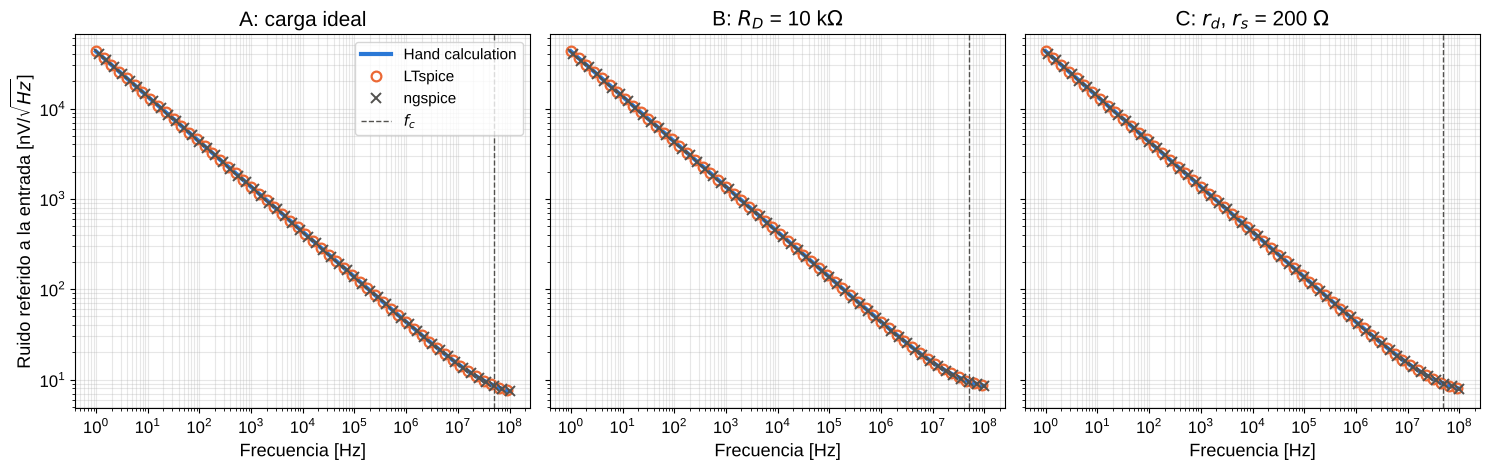

In [10]:

# Tres paneles (A, B, C) con el ruido referido a la entrada: calculo a mano, LTspice, ngspice y esquina
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

titulos = ["A: carga ideal", r"B: $R_D$ = 10 k$\Omega$", r"C: $r_d$, $r_s$ = 200 $\Omega$"]
curvas_hand = [Sin_A_hand, Sin_B_hand, Sin_C_hand]
curvas_lt = [Sin_A_sim, Sin_B_sim, Sin_C_sim]
curvas_ng = [Sin_A_ng, Sin_B_ng, Sin_C_ng]
esquinas = [fc_A, fc_B, fc_C]

for ax, titulo, h, s, n, fc in zip(axes, titulos, curvas_hand, curvas_lt, curvas_ng, esquinas):
    ax.loglog(f, np.sqrt(h) * 1e9, linewidth=3, color=C_HAND, label="Hand calculation")
    ax.loglog(f[::3], np.sqrt(s[::3]) * 1e9, 'o', markersize=7, mfc='none', mew=1.6, color=C_SIM, label="LTspice")
    ax.loglog(f[1::3], np.sqrt(n[1::3]) * 1e9, 'x', markersize=7, mew=1.4, color=C_AUX, label="ngspice")
    ax.axvline(fc, color=C_AUX, linestyle='--', linewidth=1, label=r"$f_c$")
    ax.set_title(titulo, fontsize=15, weight='normal')
    ax.set_xlabel("Frecuencia [Hz]", fontsize=13)
    ax.tick_params(labelsize=12)
    ax.grid(which='both', alpha=0.3)

axes[0].set_ylabel(r"Ruido referido a la entrada [nV/$\sqrt{Hz}$]", fontsize=13)
axes[0].legend(fontsize=11, loc="upper right")
fig.tight_layout()
plt.show()


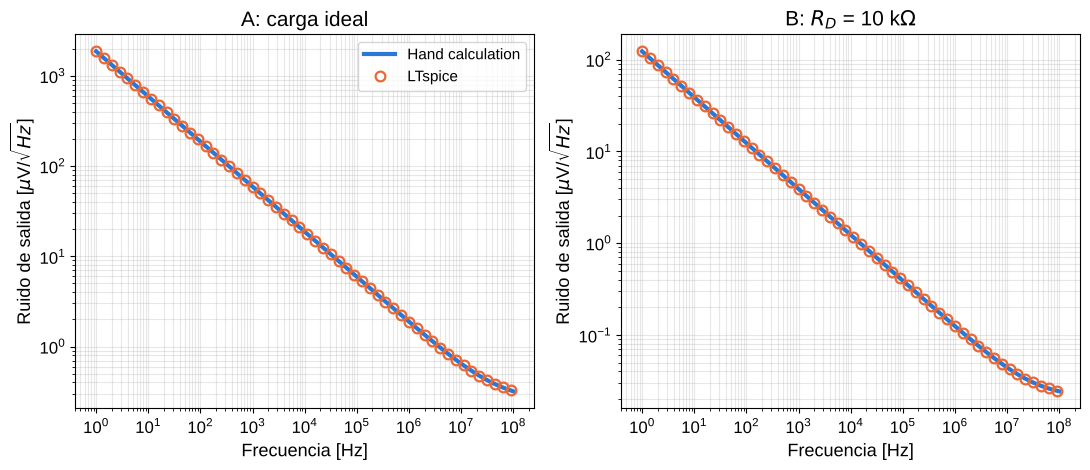

In [11]:
# Dos paneles (A y B) con el ruido de salida
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

titulos = ["A: carga ideal", r"B: $R_D$ = 10 k$\Omega$"]
curvas_hand = [Sout_A_hand, Sout_B_hand]
curvas_sim = [Sout_A_sim, Sout_B_sim]

for ax, titulo, h, s in zip(axes, titulos, curvas_hand, curvas_sim):
    ax.loglog(f, np.sqrt(h) * 1e6, linewidth=3, color=C_HAND, label="Hand calculation")
    ax.loglog(f[::3], np.sqrt(s[::3]) * 1e6, 'o', markersize=7, mfc='none', mew=1.6, color=C_SIM, label="LTspice")
    ax.set_title(titulo, fontsize=15, weight='normal')
    ax.set_xlabel("Frecuencia [Hz]", fontsize=13)
    ax.set_ylabel(r"Ruido de salida [$\mu$V/$\sqrt{Hz}$]", fontsize=13)
    ax.tick_params(labelsize=12)
    ax.grid(which='both', alpha=0.3)

axes[0].legend(fontsize=11, loc="upper right")
fig.tight_layout()
plt.show()

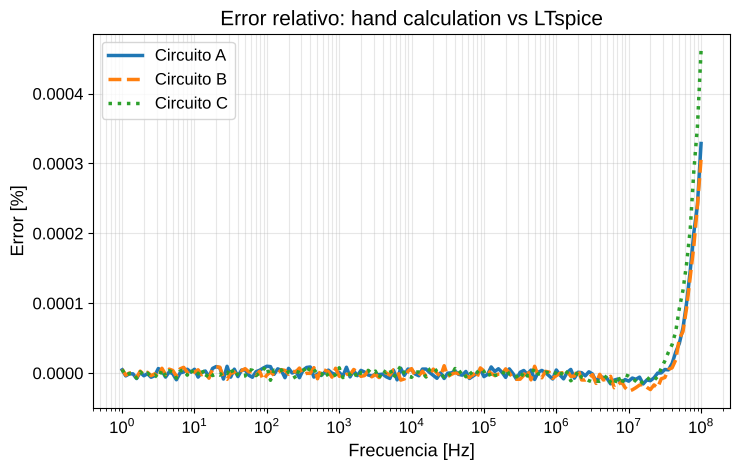

In [12]:
# Error relativo (hand calculation / ngspice - 1) en porcentaje, para los tres circuitos
plt.figure(figsize=(7.5, 4.8))
plt.semilogx(f, (Sin_A_hand / Sin_A_sim - 1) * 100, "-", linewidth=2.5, label="Circuito A")
plt.semilogx(f, (Sin_B_hand / Sin_B_sim - 1) * 100, "--", linewidth=2.5, label="Circuito B")
plt.semilogx(f, (Sin_C_hand / Sin_C_sim - 1) * 100, ":", linewidth=2.5, label="Circuito C")
plt.title("Error relativo: hand calculation vs LTspice", fontsize=15, weight='normal')
plt.xlabel("Frecuencia [Hz]", fontsize=13)
plt.ylabel("Error [%]", fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(which='both', alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


## Qué pasaría con el mismo `kf` en los dos simuladores

Si en LTspice se usara el $K_F=3\times10^{-29}$ de ngspice, el flicker sería ~$10^{5}$ veces menor en potencia y la esquina caería a cientos de Hz. La siguiente celda lo calcula con la expresión de LTspice y con la de ngspice para el circuito A.


In [13]:

# Paso 1: kf de ngspice (3e-29) usado en la formula de LTspice: S_vin,fl(1 Hz) = kf / (W * L * Cox)
S_vin_fl_LT_con_kf_ng = kf_ng / (W * L * Cox)
S_vin_th_A = S_id_th_A / gm_A**2

# Paso 2: la misma esquina y el ruido a 1 Hz
fc_LT_con_kf_ng = S_vin_fl_LT_con_kf_ng / S_vin_th_A
print(f"LTspice con kf = {kf_ng:.0e}: sqrt(S_Vin,fl) a 1 Hz = {np.sqrt(S_vin_fl_LT_con_kf_ng) * 1e9:.0f} nV/rtHz, fc = {fc_LT_con_kf_ng:.0f} Hz")
print(f"ngspice con kf = {kf_ng:.0e}: sqrt(S_Vin,fl) a 1 Hz = {np.sqrt(S_vin_fl_ng_A) * 1e6:.1f} uV/rtHz, fc = {num2eng(kf_ng * ID_A**af / (W * L * Cox**2 * S_id_th_A))}Hz")

# Paso 3: kf de LTspice que da el mismo flicker que ngspice (circuito A, VDS = 0.9 V)
kf_lt_equivalente = kf_ng * L / (2 * kp * W * Cox * (1 + lmbda * VDS_A))
print(f"kf de LTspice equivalente al kf de ngspice (W = 1u, L = 0.18u, VDS = 0.9 V): {kf_lt_equivalente:.3e}   (libreria: {kf:.2e})")


LTspice con kf = 3e-29: sqrt(S_Vin,fl) a 1 Hz = 139 nV/rtHz, fc = 529 Hz
ngspice con kf = 3e-29: sqrt(S_Vin,fl) a 1 Hz = 43.0 uV/rtHz, fc = 50.6 MHz
kf de LTspice equivalente al kf de ngspice (W = 1u, L = 0.18u, VDS = 0.9 V): 2.869e-24   (libreria: 2.87e-24)



## Resumen

* Los tres netlists de LTspice reproducen los circuitos de ngspice; las diferencias están en el flicker, no en la topología.
* **Ruido térmico**: igual en LTspice y ngspice. $S_{I_D,th}=4kT\cdot\frac23 g_m$ y $4kT/R$ de $R_D$, $r_d$ y $r_s$.
* **Ruido flicker**: ngspice usa $K_FI_D^{A_F}/(f\,WLC_{ox}^2)$ y LTspice usa $K_Fg_m^2/(f\,WLC_{ox})$. El `kf` no es transferible entre simuladores; para $W=1\,\mu$m, $L=0.18\,\mu$m y $V_{DS}=0.9$ V, $K_{F,LT}\approx9.6\times10^{4}K_{F,ng}$.
* Con los $K_F$ de cada librería, el cálculo a mano, LTspice y ngspice coinciden, y el flicker del NMOS vale 43 µV/$\sqrt{\text{Hz}}$ a 1 Hz con esquina cerca de 51 MHz.
* Si se cambia $W$, $L$ o la polarización, hay que recalcular el `kf` de LTspice, porque en LTspice el flicker escala como $1/(WL)$ y en ngspice como $1/W^2$ (a igual $L$ y polarización).
